In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1 Creare un set di dati di esempio.
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           random_state=1, n_clusters_per_class=1)

# 2. Suddividere i dati e scalarli
# ( Le SVM sono molto sensibili alla scala delle feature!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Creare e addestrare il modello SVM
# Usiamo un kernel RBG, un valore C=1.0 e una gamma 'auto'
# kerne: 'linear','poly','rbf','sigmoid'
# C: Parametro di regolarizzazione (float)
# gamma: Coefficiente del kernel 'rbf','poly' e 'sigmoid'

modello_svm = SVC(kernel='rbf', C=1.0, gamma='auto')

# Addestramento
modello_svm.fit(X_train_scaled, y_train)

# 4. Eseguire le previsioni
y_pred = modello_svm.predict(X_test_scaled)

# 5. Valutare il modello
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modello SVM: {accuracy * 100:.2f}%")

# Per vedere i vettori di supporto:
print(modello_svm.support_vectors_)

Esempio SVM Kernel RBF Breast Cancer

Accuratezza: 0.977

Classification Report:
               precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        64
      benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



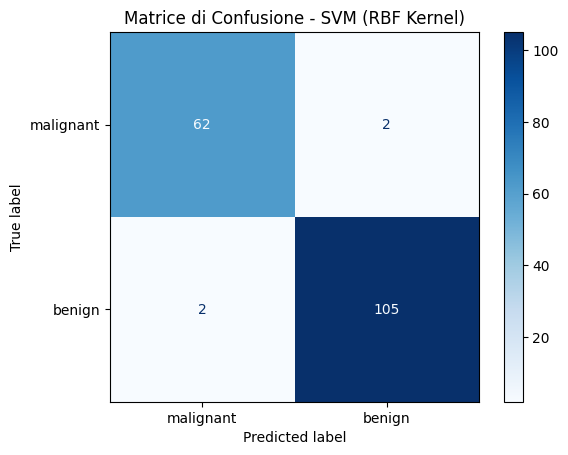

In [3]:
# ==============================================================================
# Support Vector Machine con kernel gaussiano (RBF)
# Dataset: Breast Cancer di scikit-learn
# ==============================================================================

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Caricamento del dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Suddivisione in training e test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Normalizzazione delle feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Creazione del modello SVM con kernel RBF (gaussiano)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)

# 5. Addestramento del modello
svm_rbf.fit(X_train, y_train)

# 6. Predizione sul test set
y_pred = svm_rbf.predict(X_test)

# 7. Valutazione delle prestazioni
print("Accuratezza:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))

# 8. Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Matrice di Confusione - SVM (RBF Kernel)")
plt.show()